# Análisis básico e interactivo de un corpus de textos

Este notebook toma como base el ejercicio original de **Análisis de textos** y conserva su enfoque pedagógico: cargar varios documentos, normalizarlos, construir representaciones numéricas y estudiar qué palabras caracterizan a cada texto.

Se amplía el ejercicio con:

- normalización homogénea de todos los documentos;
- bolsa de palabras y **frecuencia de términos** por documento;
- **nube de palabras (WordCloud)** por documento;
- análisis **TF–IDF** y comparación de los términos más representativos;
- análisis de **bigramas** por documento;
- explorador interactivo para seleccionar un documento y visualizar conjuntamente sus resultados.

## 1. Librerías y carga de los documentos

Se utilizan los mismos cinco textos del notebook original. El primer archivo se lee con codificación `latin1`, tal como estaba planteado inicialmente; para los demás se prueba primero UTF-8 y, si es necesario, Latin-1.

In [ ]:
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

try:
    from wordcloud import WordCloud
except ImportError:
    raise ImportError("Instala wordcloud con: pip install wordcloud")

nltk.download('stopwords', quiet=True)

# Descarga de los mismos textos utilizados en el notebook original
!wget -q 'https://www.robertohincapie.com/data/libro_muertos.txt'
!wget -q 'https://www.robertohincapie.com/data/constitucion.txt'
!wget -q 'https://www.robertohincapie.com/data/libro1.txt'
!wget -q 'https://www.robertohincapie.com/data/novela1.txt'
!wget -q 'https://www.robertohincapie.com/data/principito.txt'

archivos = [
    'libro_muertos.txt',
    'constitucion.txt',
    'libro1.txt',
    'novela1.txt',
    'principito.txt'
]

nombres = [
    'Libro de los muertos',
    'Constitución',
    'Libro 1',
    'Novela 1',
    'El Principito'
]


def leer_texto(ruta, encoding_preferido='utf-8'):
    try:
        with open(ruta, encoding=encoding_preferido) as f:
            return f.read()
    except UnicodeDecodeError:
        with open(ruta, encoding='latin1') as f:
            return f.read()

textos_originales = []
for i, archivo in enumerate(archivos):
    enc = 'latin1' if i == 0 else 'utf-8'
    textos_originales.append(leer_texto(archivo, enc))

print(f'Se cargaron {len(textos_originales)} documentos.')
for nombre, texto in zip(nombres, textos_originales):
    print(f'{nombre:22s}: {len(texto):,} caracteres')

Se cargaron 5 documentos.
Libro de los muertos  : 46,134 caracteres
Constitución          : 405,102 caracteres
Libro 1               : 253,349 caracteres
Novela 1              : 95,418 caracteres
El Principito         : 78,313 caracteres


## 2. Normalización

La normalización conserva la lógica del notebook original:

1. convierte el texto a minúsculas;
2. conserva letras del español, incluidos `áéíóúñ`;
3. reemplaza los demás caracteres por espacios;
4. elimina espacios repetidos;
5. elimina *stopwords* del español y algunos numerales romanos usados en el ejercicio original.

No se aplica *stemming* ni lematización para que el análisis permanezca fiel al material de base.

In [ ]:
stop_words = stopwords.words('spanish')
stop_words = stop_words + ['iii', 'i', 'ii', 'iv', 'v', 'vi']
stop_words = set(stop_words)

permitidos = set('áéíóúñüabcdefghijklmnopqrstuvwxyz ')


def normalizar_texto(texto, quitar_stopwords=True):
    texto = texto.lower()
    texto = ''.join(c if c in permitidos else ' ' for c in texto)
    texto = ' '.join(texto.split())

    if quitar_stopwords:
        tokens = [p for p in texto.split() if p not in stop_words]
        texto = ' '.join(tokens)

    return texto


docs_sin_stopwords = [normalizar_texto(t, quitar_stopwords=True) for t in textos_originales]
docs_con_stopwords = [normalizar_texto(t, quitar_stopwords=False) for t in textos_originales]

resumen = pd.DataFrame({
    'Documento': nombres,
    'Caracteres originales': [len(t) for t in textos_originales],
    'Palabras normalizadas': [len(t.split()) for t in docs_sin_stopwords],
    'Vocabulario': [len(set(t.split())) for t in docs_sin_stopwords]
})
resumen

,Documento,Caracteres originales,Palabras normalizadas,Vocabulario
0,Libro de los muertos,46134,3898,1648
1,Constitución,405102,31094,4950
2,Libro 1,253349,22069,6270
3,Novela 1,95418,7618,3697
4,El Principito,78313,6414,2141


## 3. Bolsa de palabras y frecuencia de términos

Una bolsa de palabras representa cada documento mediante el número de veces que aparece cada término. Aquí se construye una única matriz documento–término, de modo que **todos los documentos compartan el mismo vocabulario**.

In [ ]:
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(docs_sin_stopwords)
terminos = count_vectorizer.get_feature_names_out()

df_frecuencias = pd.DataFrame(
    X_count.toarray(),
    index=nombres,
    columns=terminos
)

print('Dimensiones de la matriz documento-término:', df_frecuencias.shape)
df_frecuencias.iloc[:, :10]

Dimensiones de la matriz documento-término: (5, 13979)


,abadía,abajo,abandona,abandonado,abandonar,abandone,abandono,abandoné,abandonó,abdomen
Libro de los muertos,0,0,0,0,1,0,0,0,0,0
Constitución,0,0,0,0,0,0,3,0,0,0
Libro 1,1,3,0,1,3,1,0,0,0,0
Novela 1,0,4,0,1,0,0,0,0,0,1
El Principito,0,3,1,2,1,0,0,1,1,0


### Términos más frecuentes de cada documento

La siguiente función devuelve y grafica los términos con mayor frecuencia absoluta de un documento.

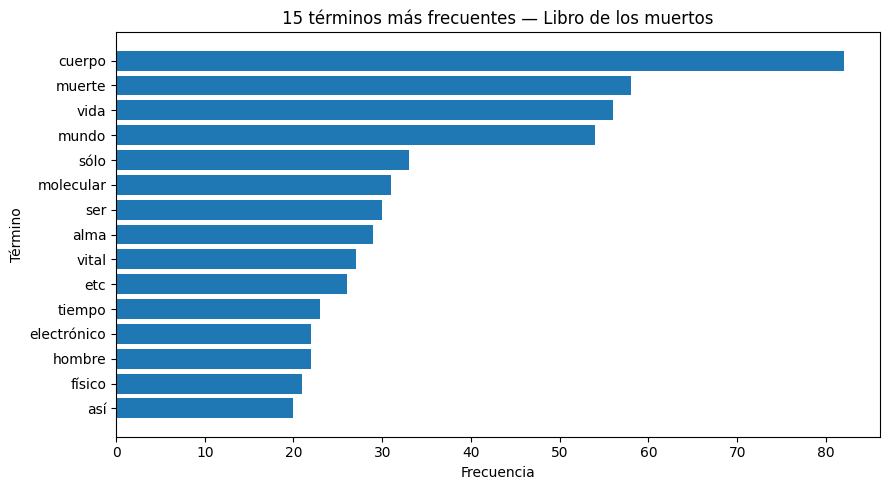

,término,frecuencia
0,cuerpo,82
1,muerte,58
2,vida,56
3,mundo,54
4,sólo,33
5,molecular,31
6,ser,30
7,alma,29
8,vital,27
9,etc,26


In [ ]:
def terminos_mas_frecuentes(indice_doc, n=15):
    serie = df_frecuencias.iloc[indice_doc]
    top = serie[serie > 0].sort_values(ascending=False).head(n)
    return pd.DataFrame({'término': top.index, 'frecuencia': top.values})


def graficar_frecuencias(indice_doc, n=15):
    top = terminos_mas_frecuentes(indice_doc, n)
    plt.figure(figsize=(9, 5))
    plt.barh(top['término'][::-1], top['frecuencia'][::-1])
    plt.xlabel('Frecuencia')
    plt.ylabel('Término')
    plt.title(f'{n} términos más frecuentes — {nombres[indice_doc]}')
    plt.tight_layout()
    plt.show()
    return top

# Ejemplo
graficar_frecuencias(0, 15)

## 4. WordCloud de cada documento

La nube de palabras usa el mismo texto normalizado. El tamaño visual de una palabra es proporcional a su frecuencia dentro del documento.

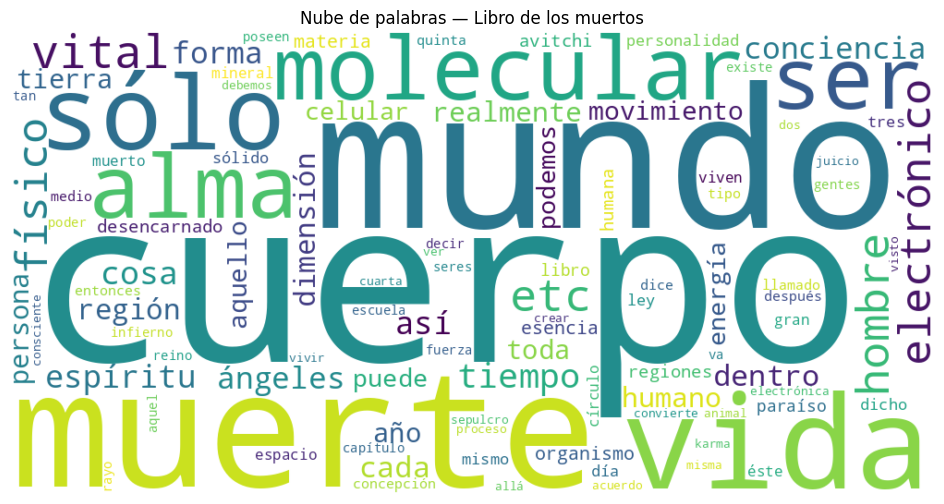

In [ ]:
def mostrar_wordcloud(indice_doc, max_words=100):
    texto = docs_sin_stopwords[indice_doc]
    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=max_words,
        collocations=False
    ).generate(texto)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nube de palabras — {nombres[indice_doc]}')
    plt.show()

# Ejemplo
mostrar_wordcloud(0)

## 5. Análisis TF–IDF

La frecuencia absoluta favorece palabras que aparecen muchas veces, incluso si también son habituales en los demás documentos. TF–IDF intenta resaltar los términos que son **frecuentes dentro de un documento pero menos comunes en el resto del corpus**.

Para un término $t$ y un documento $d$ puede pensarse, de forma conceptual, como:

$$
TFIDF(t,d)=TF(t,d)	imes IDF(t)
$$

En `scikit-learn`, `TfidfVectorizer` calcula esta representación y normaliza los vectores resultantes.

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(docs_sin_stopwords)
terminos_tfidf = tfidf_vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    index=nombres,
    columns=terminos_tfidf
)

print('Dimensiones TF-IDF:', df_tfidf.shape)
df_tfidf.iloc[:, :10]

Dimensiones TF-IDF: (5, 13979)


,abadía,abajo,abandona,abandonado,abandonar,abandone,abandono,abandoné,abandonó,abdomen
Libro de los muertos,0.000000,0.000000,0.000000,0.000000,0.005326,0.000000,0.000000,0.000000,0.000000,0.000000
Constitución,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002466,0.000000,0.000000,0.000000
Libro 1,0.001817,0.003650,0.000000,0.001217,0.003650,0.001817,0.000000,0.000000,0.000000,0.000000
Novela 1,0.000000,0.014365,0.000000,0.003591,0.000000,0.000000,0.000000,0.000000,0.000000,0.005362
El Principito,0.000000,0.007375,0.003671,0.004917,0.002458,0.000000,0.000000,0.003671,0.003671,0.000000


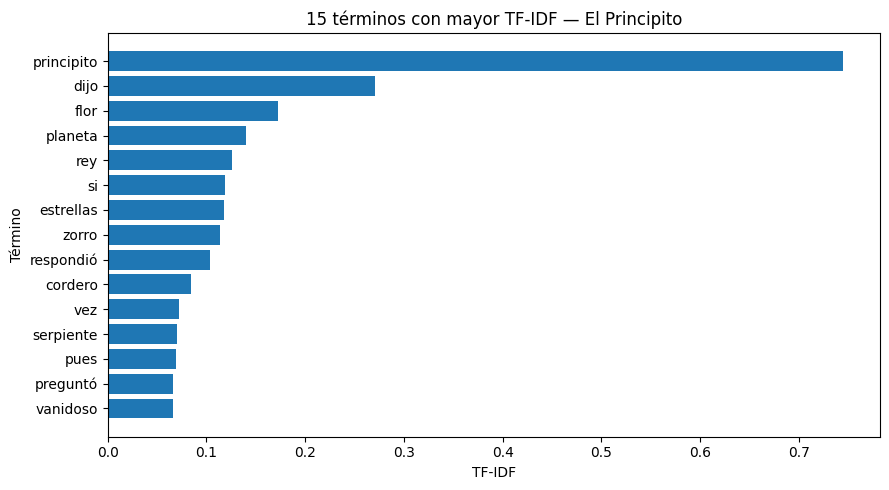

,término,tf-idf
0,principito,0.745136
1,dijo,0.270903
2,flor,0.172519
3,planeta,0.140121
4,rey,0.126146
5,si,0.118937
6,estrellas,0.117996
7,zorro,0.113789
8,respondió,0.103247
9,cordero,0.084424


In [ ]:
def terminos_tfidf(indice_doc, n=15):
    serie = df_tfidf.iloc[indice_doc]
    top = serie[serie > 0].sort_values(ascending=False).head(n)
    return pd.DataFrame({'término': top.index, 'tf-idf': top.values})


def graficar_tfidf(indice_doc, n=15):
    top = terminos_tfidf(indice_doc, n)
    plt.figure(figsize=(9, 5))
    plt.barh(top['término'][::-1], top['tf-idf'][::-1])
    plt.xlabel('TF-IDF')
    plt.ylabel('Término')
    plt.title(f'{n} términos con mayor TF-IDF — {nombres[indice_doc]}')
    plt.tight_layout()
    plt.show()
    return top

# Ejemplo
graficar_tfidf(4, 15)

### Comparación entre frecuencia y TF–IDF

Una palabra puede estar entre las más frecuentes de un texto y, sin embargo, no ser de las más discriminantes si también aparece abundantemente en los otros documentos. La tabla siguiente facilita esa comparación.

In [ ]:
def comparar_frecuencia_tfidf(indice_doc, n=15):
    frec = terminos_mas_frecuentes(indice_doc, n).rename(columns={'frecuencia': 'valor'})
    frec['medida'] = 'Frecuencia'

    tfidf = terminos_tfidf(indice_doc, n).rename(columns={'tf-idf': 'valor'})
    tfidf['medida'] = 'TF-IDF'

    return frec, tfidf

for i, nombre in enumerate(nombres):
    print()
    print('=' * 80)
    print(nombre)
    print('Más frecuentes:')
    display(terminos_mas_frecuentes(i, 10))
    print('Mayor TF-IDF:')
    display(terminos_tfidf(i, 10))


Libro de los muertos
Más frecuentes:


,término,frecuencia
0,cuerpo,82
1,muerte,58
2,vida,56
3,mundo,54
4,sólo,33
5,molecular,31
6,ser,30
7,alma,29
8,vital,27
9,etc,26


Mayor TF-IDF:


,término,tf-idf
0,cuerpo,0.367387
1,molecular,0.246529
2,mundo,0.241937
3,muerte,0.219787
4,vida,0.212208
5,etc,0.166818
6,alma,0.154451
7,vital,0.143800
8,dimensión,0.135193
9,sólo,0.125051



Constitución
Más frecuentes:


...

,término,tf-idf
0,sr,0.278848
1,usted,0.272939
2,pepe,0.268123
3,dijo,0.235648
4,perfecta,0.190362
5,doña,0.171599
6,licurgo,0.150149
7,josé,0.147098
8,orbajosa,0.144787
9,si,0.132873



El Principito
Más frecuentes:


,término,frecuencia
0,principito,203
1,dijo,131
2,si,68
3,rey,61
4,planeta,57
5,estrellas,48
6,flor,47
7,respondió,42
8,vez,41
9,tan,34


Mayor TF-IDF:


,término,tf-idf
0,principito,0.745136
1,dijo,0.270903
2,flor,0.172519
3,planeta,0.140121
4,rey,0.126146
5,si,0.118937
6,estrellas,0.117996
7,zorro,0.113789
8,respondió,0.103247
9,cordero,0.084424


## 6. Bigramas

Un **bigrama** es una secuencia de dos términos consecutivos. A diferencia de la bolsa de palabras, permite capturar una pequeña cantidad de estructura local, por ejemplo expresiones como `poder público`, `ser humano` o cualquier pareja recurrente propia de un documento.

Se calculan después de la misma normalización y eliminación de *stopwords* utilizada anteriormente.

In [ ]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_bigram = bigram_vectorizer.fit_transform(docs_sin_stopwords)
bigramas = bigram_vectorizer.get_feature_names_out()

df_bigramas = pd.DataFrame(
    X_bigram.toarray(),
    index=nombres,
    columns=bigramas
)

print('Número total de bigramas diferentes:', len(bigramas))

Número total de bigramas diferentes: 55101


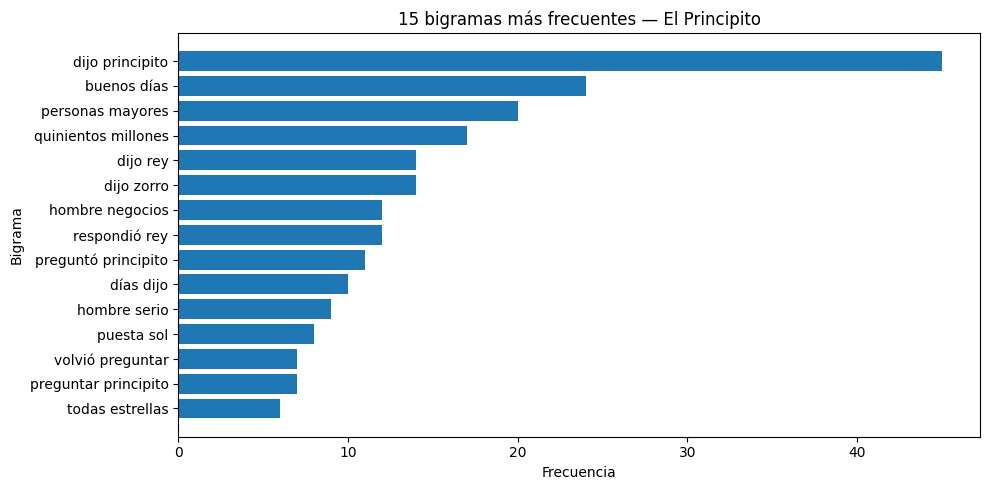

,bigrama,frecuencia
0,dijo principito,45
1,buenos días,24
2,personas mayores,20
3,quinientos millones,17
4,dijo rey,14
5,dijo zorro,14
6,hombre negocios,12
7,respondió rey,12
8,preguntó principito,11
9,días dijo,10


In [ ]:
def bigramas_mas_frecuentes(indice_doc, n=15):
    serie = df_bigramas.iloc[indice_doc]
    top = serie[serie > 0].sort_values(ascending=False).head(n)
    return pd.DataFrame({'bigrama': top.index, 'frecuencia': top.values})


def graficar_bigramas(indice_doc, n=15):
    top = bigramas_mas_frecuentes(indice_doc, n)
    plt.figure(figsize=(10, 5))
    plt.barh(top['bigrama'][::-1], top['frecuencia'][::-1])
    plt.xlabel('Frecuencia')
    plt.ylabel('Bigrama')
    plt.title(f'{n} bigramas más frecuentes — {nombres[indice_doc]}')
    plt.tight_layout()
    plt.show()
    return top

# Ejemplo
graficar_bigramas(4, 15)

## 7. Explorador interactivo por documento

Seleccione un documento para obtener en un solo lugar:

- métricas básicas del texto;
- términos más frecuentes;
- nube de palabras;
- términos con mayor TF–IDF;
- bigramas más frecuentes.

Si `ipywidgets` no está disponible en el entorno, puede instalarse con `pip install ipywidgets` o llamar directamente a `analizar_documento(indice)`.

In [ ]:
def analizar_documento(indice_doc=0, n=15):
    print('=' * 90)
    print(nombres[indice_doc])
    print('=' * 90)
    print('Palabras normalizadas :', len(docs_sin_stopwords[indice_doc].split()))
    print('Vocabulario           :', len(set(docs_sin_stopwords[indice_doc].split())))

    print()
    print('Términos más frecuentes')
    display(terminos_mas_frecuentes(indice_doc, n))
    graficar_frecuencias(indice_doc, n)

    print()
    print('Nube de palabras')
    mostrar_wordcloud(indice_doc)

    print()
    print('Términos con mayor TF-IDF')
    display(terminos_tfidf(indice_doc, n))
    graficar_tfidf(indice_doc, n)

    print()
    print('Bigramas más frecuentes')
    display(bigramas_mas_frecuentes(indice_doc, n))
    graficar_bigramas(indice_doc, n)

try:
    import ipywidgets as widgets

    selector = widgets.Dropdown(
        options=[(nombre, i) for i, nombre in enumerate(nombres)],
        value=0,
        description='Documento:'
    )
    top_n = widgets.IntSlider(
        value=15,
        min=5,
        max=30,
        step=5,
        description='Top N:'
    )

    salida = widgets.interactive_output(
        analizar_documento,
        {'indice_doc': selector, 'n': top_n}
    )

    display(widgets.VBox([selector, top_n]), salida)
except ImportError:
    print('ipywidgets no está instalado. Ejecute, por ejemplo: analizar_documento(0, 15)')

Output()

## 8. Tabla resumen de los resultados principales

Para cerrar el ejercicio se genera una tabla compacta que muestra, por documento, sus cinco términos más frecuentes, cinco términos con mayor TF–IDF y cinco bigramas más frecuentes.

In [ ]:
filas = []
for i, nombre in enumerate(nombres):
    top_f = terminos_mas_frecuentes(i, 5)
    top_t = terminos_tfidf(i, 5)
    top_b = bigramas_mas_frecuentes(i, 5)

    filas.append({
        'Documento': nombre,
        'Top frecuencia': ', '.join(top_f['término']),
        'Top TF-IDF': ', '.join(top_t['término']),
        'Top bigramas': ', '.join(top_b['bigrama'])
    })

resumen_final = pd.DataFrame(filas)
resumen_final

,Documento,Top frecuencia,Top TF-IDF,Top bigramas
0,Libro de los muertos,"cuerpo, muerte, vida, mundo, sólo","cuerpo, molecular, mundo, muerte, vida","cuerpo vital, ángeles muerte, mundo molecular,..."
1,Constitución,"artículo, ley, constitución, acto, legislativo","artículo, ley, legislativo, constitución, artí...","acto legislativo, artículo constitución, const..."
2,Libro 1,"personas, john, usted, si, demás","john, usted, personas, si, demás","si usted, propia vida, momento enseñanza, esti..."
3,Novela 1,"dijo, usted, sr, si, aquí","sr, usted, pepe, dijo, perfecta","doña perfecta, sr josé, pepe rey, tío licurgo,..."
4,El Principito,"principito, dijo, si, rey, planeta","principito, dijo, flor, planeta, rey","dijo principito, buenos días, personas mayores..."


## 9. Lectura conceptual de los resultados

El ejercicio permite comparar tres perspectivas distintas sobre cada documento:

- **Frecuencia:** responde cuáles son las palabras que más se repiten dentro del texto.
- **TF–IDF:** responde cuáles son las palabras relativamente más características de ese documento frente a los demás textos del corpus.
- **Bigramas:** responde cuáles son las parejas de palabras que aparecen juntas con mayor frecuencia y aporta una primera aproximación a la estructura local del lenguaje.

Por esta razón no debe esperarse que los términos más frecuentes sean exactamente los mismos que los de mayor TF–IDF. Una palabra muy frecuente puede tener poco poder discriminante si también aparece repetidamente en los otros documentos. Los bigramas, por su parte, pueden revelar expresiones recurrentes que un análisis de palabras aisladas no permite detectar.